# Ensemble Evolution

A two-time correlation follows how a measurement at a later time relates to an
operator applied to the initial state. Averaging these correlations over several
initial states helps study spin dynamics and transport. This guide starts with
one state, compares it with a small ensemble, and then follows local
spin-current correlations in a periodic chain. All evolution is unitary.

This guide uses the standard YAQS installation and Matplotlib. Run the cells in
order in a notebook. For a script, use the entry-point guard in
{doc}`simulator_initialization`.

## 1. Follow one state in an open spin chain

Use six spin-$1/2$ sites with nearest-neighbor XXZ interactions and a transverse
field. With $S^\alpha=\sigma^\alpha/2$, the Hamiltonian is

```{math}
H = \sum_{r=0}^{L-2}\left[
J_{xx}(S_r^x S_{r+1}^x+S_r^y S_{r+1}^y)
+\Delta S_r^z S_{r+1}^z\right]
+h_x\sum_{r=0}^{L-1}S_r^x.
```

`Hamiltonian.pauli` uses Pauli matrices, so two-spin coefficients include a
factor of $1/4$ and the field coefficient includes $1/2$. Set $J_{xx}=1$ and
$\hbar=1$, so time is in units of $1/J_{xx}$.

In [1]:
import numpy as np

from mqt.yaqs import AnalogSimParams, Hamiltonian, Observable, Simulator, State

L = 6
Jxx = 1.0
delta = 0.7
h_x = 0.4
H_open = Hamiltonian.pauli(
    length=L,
    two_body=[(0.25 * Jxx, "X", "X"), (0.25 * Jxx, "Y", "Y"), (0.25 * delta, "Z", "Z")],
    one_body=[(0.5 * h_x, "X")],
    bc="open",
)
mid = L // 2
psi0 = State(L, initial="haar-random", pad=2)
sim = Simulator(show_progress=False)

The `haar-random` preset builds a random MPS from Haar-random isometries. Here,
`pad=2` limits its initial bond dimension to two. This is not a uniformly
sampled vector from the full Hilbert space. State initialization is unseeded, so
rerunning the notebook changes the numerical curves. Save the initial MPS
tensors when you need to reproduce a particular ensemble.

First measure the central site's Pauli $Z$ expectation. `Observable("z", mid)`
represents $\sigma^z_m$; divide its expectation by two for $S^z_m$.

In [2]:
primer_params = AnalogSimParams(
    observables=[Observable("z", mid)],
    elapsed_time=5.1,
    dt=0.15,
    max_bond_dim=64,
    svd_threshold=1e-10,
)
result_primer = sim.run(psi0, H_open, primer_params)
times_primer = result_primer.times
zexp_primer = result_primer.expectation_values[0]

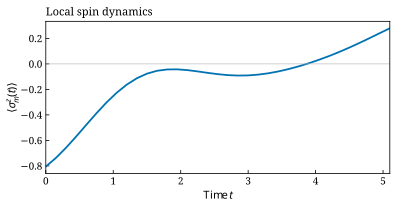

In [3]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["STIXGeneral"], "mathtext.fontset": "stix",
    "font.size": 10, "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in", "svg.fonttype": "none",
    "legend.frameon": False,
})
fig, ax = plt.subplots(figsize=(5.4, 2.8), layout="constrained")
ax.plot(times_primer, zexp_primer, color="#0072B2", linewidth=1.8)
ax.axhline(0, color="0.7", linewidth=0.6)
ax.set(xlabel=r"Time $t$", ylabel=r"$\langle\sigma^z_m(t)\rangle$", xlim=(0, 5.1))
ax.set_title("Local spin dynamics", loc="left", fontsize=11)
plt.show()

The local expectation changes even though the whole chain evolves unitarily. A
single curve depends on its initial state. Two-time correlations let us ask how
a specified initial perturbation affects the later dynamics.

## 2. Request two-time correlations

For a state $|\psi_0\rangle$ and propagator $U(t)$, define

```{math}
C_{AB}(t)=\langle\psi_0|U^\dagger(t)\,A\,U(t)\,B|\psi_0\rangle.
```

Pass `(A, B)` in `multi_time_observables`: `B` acts at time zero and `A` is
measured at time $t$. Setting `A` and `B` equal gives an autocorrelation. The
product need not be Hermitian, so the result can be complex.

The correlation backend takes a `list[State]` of MPS inputs. A list with one
state gives a single-state result. Reuse `psi0` to connect the correlation
calculation with the local dynamics above.

In [4]:
sz_mid = Observable("z", mid)
sx_mid = Observable("x", mid)
single_state_params = AnalogSimParams(
    observables=[],
    elapsed_time=5.1,
    dt=0.15,
    max_bond_dim=64,
    svd_threshold=1e-10,
    multi_time_observables=[(sz_mid, sz_mid), (sz_mid, sx_mid)],
)
result_single = sim.run([psi0], H_open, single_state_params)
t_single = result_single.multi_time_times
czz_single = result_single.multi_time_results[0]
czx_single = result_single.multi_time_results[1]

`multi_time_results` has shape `(2, 35)`: one row per pair, in the supplied
order, and one column per sampled time. `multi_time_times` supplies the matching
time axis. The rows contain $C_{zz}$ and $C_{zx}$ for Pauli operators; divide by
four for spin-$1/2$ correlations. In particular, $C_{zz}(0)=1$.

## 3. Average over initial states

Pass several states to average the same correlations with equal weights. Keep
the original state as the first member and add three independently initialized
random MPS. Each state evolves separately, and the list length determines the
ensemble size; `num_traj` does not set it.

In [5]:
num_states = 4
ensemble_states = [psi0, *[State(L, initial="haar-random", pad=2) for _ in range(num_states - 1)]]
ensemble_params = AnalogSimParams(
    observables=[],
    elapsed_time=5.1,
    dt=0.15,
    max_bond_dim=64,
    svd_threshold=1e-10,
    multi_time_observables=[(sz_mid, sz_mid), (sz_mid, sx_mid)],
)
result_ens = sim.run(ensemble_states, H_open, ensemble_params)
t_ens = result_ens.multi_time_times
czz_ens = result_ens.multi_time_results[0]
czx_ens = result_ens.multi_time_results[1]

`multi_time_results` now contains the ensemble mean, with the same pair and time
axes. Ordinary `observables`, if supplied, also produce ensemble means in
`expectation_values` and individual member data in `trajectories`. Per-member
two-time correlations are not exposed in `Result`.

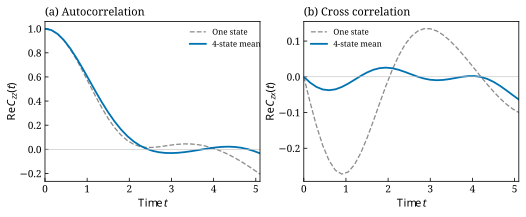

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), layout="constrained")
for ax, single, average, label in zip(
    axes, [czz_single, czx_single], [czz_ens, czx_ens], ["zz", "zx"], strict=True,
):
    ax.plot(t_single, single.real, color="0.55", linestyle="--", linewidth=1.3, label="One state")
    ax.plot(t_ens, average.real, color="#0072B2", linewidth=1.8, label=f"{num_states}-state mean")
    ax.axhline(0, color="0.75", linewidth=0.6)
    ax.set(xlabel=r"Time $t$", ylabel=rf"$\mathrm{{Re}}\,C_{{{label}}}(t)$", xlim=(0, 5.1))
    ax.legend(fontsize=8)
axes[0].set_title("(a) Autocorrelation", loc="left", fontsize=11)
axes[1].set_title("(b) Cross correlation", loc="left", fontsize=11)
plt.show()

The plots compare the real parts; the result retains both real and imaginary
components. Averaging changes the state-dependent fluctuations, but four states
do not establish a converged thermal average. This example demonstrates the
ensemble workflow. Dynamical quantum typicality uses suitable random-state
sampling to estimate traces; finite-temperature calculations also need thermal
weighting or filtering. The small random-MPS ensemble here supplies neither a
convergence study nor finite-temperature preparation.

## 4. Compare local spin-current correlations

A periodic XXZ chain lets us study how spin currents change with the interaction
strength. For each directed bond $(r,r+1)$, with site indices wrapped modulo
$L$, define

```{math}
j_r=J_{xx}\left(S_r^x S_{r+1}^y-S_r^y S_{r+1}^x\right).
```

Measure each bond's autocorrelation and average over bonds and initial states:

```{math}
C_{\mathrm{bond}}(t)=\frac{1}{L}\sum_r\langle j_r(t)j_r(0)\rangle_{\mathrm{ensemble}}.
```

The two-site matrix below follows the listed site order, including the periodic
bond `(L - 1, 0)`.

In [7]:
def spin_current_bond_matrix(j_coupling):
    x = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=complex)
    y = np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=complex)
    return 0.25 * j_coupling * (np.kron(x, y) - np.kron(y, x))


Ltr = 6
deltas = [0.1, 1.5]
states_transport = [State(Ltr, initial="haar-random", pad=2) for _ in range(2)]
j_mat = spin_current_bond_matrix(Jxx)
bond_obs = [Observable(j_mat, sites=[r, (r + 1) % Ltr]) for r in range(Ltr)]
pairs_jj = [(obs, obs) for obs in bond_obs]
transport_curves = {}
transport_results = {}
for d in deltas:
    h_periodic = Hamiltonian.pauli(
        length=Ltr,
        two_body=[(0.25 * Jxx, "X", "X"), (0.25 * Jxx, "Y", "Y"), (0.25 * d, "Z", "Z")],
        one_body=[],
        bc="periodic",
    )
    transport_params = AnalogSimParams(
        observables=[],
        elapsed_time=3.0,
        dt=0.1,
        max_bond_dim=32,
        svd_threshold=1e-10,
        multi_time_observables=pairs_jj,
    )
    result_transport = sim.run(states_transport, h_periodic, transport_params)
    t_transport = result_transport.multi_time_times
    transport_results[d] = result_transport
    transport_curves[d] = result_transport.multi_time_results.mean(axis=0)

Each `multi_time_results` array has shape `(6, 31)`, with one row for each bond.
The final mean over rows gives $C_{\mathrm{bond}}$. Reusing the same initial
states for both interaction strengths keeps the ensemble fixed.

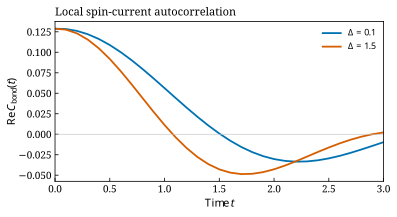

In [8]:
fig, ax = plt.subplots(figsize=(5.4, 2.9), layout="constrained")
for d, color in zip(deltas, ["#0072B2", "#D55E00"], strict=True):
    ax.plot(t_transport, transport_curves[d].real, color=color, linewidth=1.8, label=rf"$\Delta={d}$")
ax.axhline(0, color="0.75", linewidth=0.6)
ax.set(xlabel=r"Time $t$", ylabel=r"$\mathrm{Re}\,C_{\mathrm{bond}}(t)$", xlim=(0, 3))
ax.set_title("Local spin-current autocorrelation", loc="left", fontsize=11)
ax.legend(fontsize=9)
plt.show()

The curves show how the bond-current correlation depends on the interaction
strength over this short window. They are not the full total-current
correlation. For $J=\sum_r j_r$, the latter contains all cross-bond terms,
$C_{JJ}(t)=L^{-1}\sum_{r,s}\langle j_r(t)j_s(0)\rangle$. Computing it requires
$L^2$ operator pairs instead of the $L$ pairs used here.

These small-chain curves do not determine a diffusion constant or a Drude
weight. For the connection between typicality and current correlations, see
[Steinigeweg et al., Phys. Rev. Lett. **112**, 120601 (2014)](https://doi.org/10.1103/PhysRevLett.112.120601).
The broader transport setting is covered in
[Bertini et al., Rev. Mod. Phys. **93**, 025003 (2021)](https://doi.org/10.1103/RevModPhys.93.025003).

## Scale the calculation

Parallel execution is enabled by default for ensembles with several members. The
documentation suppresses progress with `show_progress=False`; omit that setting
to see progress. Increase the number of initial states to check sampling
convergence, and check timestep and bond-dimension convergence separately. The
random state's initial `pad` and the evolution's `max_bond_dim` serve different
purposes. Longer evolution can require larger bonds as entanglement grows.

The list-of-state path requires MPS inputs and a static Hamiltonian. It returns
ensemble observables and correlations, rather than a final ensemble state.

## Related guides

- {doc}`analog_simulation` — single-state analog evolution and numerical
  settings.
- {doc}`state_initialization` — random MPS, custom states, and list inputs.
- {doc}`simulator_initialization` — parallel workers and script execution.